# Loading csv data and checking all the selected websites were recorded

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

WEBSITES = [
    "https://www.udemy.com/",
    "https://www.sofi.com/",
    "https://www.connectwise.com/",
    "https://www.delta.com/",
    "https://www.colliers.com/",
    "https://www.airtahiti.com/",
    "https://chatgpt.com/",
    "https://pos.toasttab.com/",
    "https://www.eon.com/",
    "https://www.crowe.com/",
    "https://www.lego.com/",
    "https://www.web.com/",
    "https://www.cummins.com/",
    "https://www.researchgate.net/",
    "https://www.abbvie.com/",
    "https://grok.com",
    "https://claude.ai/new",
    "https://jobs.experian.com/jobs",
    "https://rtcamp.com/",
    "https://www.amp.com.au/",
    "https://www.amtrak.com/home",
    "https://www.axi.com/int",
    "https://www.cardinalhealth.com/en.html",
    "https://www.cvent.com/",
    "https://www.interface.com/US/en-US.html",
    "https://www.moodys.com/",
    "https://www.sierrawireless.com/",
    "https://www.slb.com/",
    "https://www.travelers.com/",
    "https://www.weber.com/US/en/home/",
    "https://www.cookieyes.com/",
    "https://www.veeam.com/",
    "https://www.riotgames.com/en",
    "https://www.shopify.com/login",
    "https://dashboard.stripe.com/login",
    "https://www.epicgames.com/id/login",
    "https://store.steampowered.com/join",
    "https://www.bader.at/meinbader/anmeldung",
    "https://www.goyard.com/us_en/customer/account/create/referer/",
    "https://www.monamoda.nl/mijnaccount/aanmelding",
    "https://www.klingel.nl/mijnaccount/aanmelding",
    "https://www.ghd.com/en/contact-us",
    "https://www.brigitte-salzburg.at/meinkonto/anmeldung",
    "https://amperecomputing.com/auth/register",
    "https://edpuzzle.com/",
    "https://admin.mtcaptcha.com/signup/profile?plantype=A",
    'https://www.maximiles.com/',
    'https://www.qcitymetro.com/'    
]

PURE_SELENIUM_GUI = pd.read_csv("./Pure-Selenium-GUI/Pure-Selenium-GUI.csv")
PURE_SELENIUM_HEADLESS = pd.read_csv("./Pure-Selenium-Headless/Pure-Selenium-Headless.csv")

NON_MOBILE_GUI = pd.read_csv("./Non-Mobile-GUI/Non-Mobile-Browser-Headers-Selenium-GUI.csv")
NON_MOBILE_HEADLESS = pd.read_csv("./Non-Mobile-Headless/Non-Mobile-Browser-Headers-Selenium-Headless.csv")

MOBILE_GUI = pd.read_csv("./Mobile-GUI/Mobile-Browser-Headers-Selenium-GUI.csv")
MOBILE_HEADLESS = pd.read_csv("./Mobile-Headless/Mobile-Browser-Headers-Selenium-Headless.csv")

UD_GUI = pd.read_csv("./UD-GUI/Undetected-Browser-Selenium-GUI.csv")
UD_HEADLESS = pd.read_csv("./UD-Headless/Undetected-Browser-Selenium-Headless.csv")

SCRAPEOPS_GUI = pd.read_csv("./ScrapeOPSProxy-GUI/ScrapeOPS-Proxy-Selenium-GUI.csv")
SCRAPEOPS_HEADLESS = pd.read_csv("./ScrapeOPSProxy-Headless/ScrapeOPS-Proxy-Selenium-Headless.csv")

assert PURE_SELENIUM_GUI.shape[0] == len(WEBSITES)
assert PURE_SELENIUM_HEADLESS.shape[0] == len(WEBSITES)

assert NON_MOBILE_GUI.shape[0] == len(WEBSITES)
assert NON_MOBILE_HEADLESS.shape[0] == len(WEBSITES)

assert MOBILE_GUI.shape[0] == len(WEBSITES)
assert MOBILE_HEADLESS.shape[0] == len(WEBSITES)

assert UD_GUI.shape[0] == len(WEBSITES)
assert UD_HEADLESS.shape[0] == len(WEBSITES)

assert SCRAPEOPS_GUI.shape[0] == len(WEBSITES) 
assert SCRAPEOPS_HEADLESS.shape[0] == len(WEBSITES) 

# SUCCESS = green, FAIL = red
CAPTCHA_COLORS = {
    "HARD BLOCK BY WEBSITE": "blue",
    "NO CAPTCHA DETECTED": "yellow",
    "CLOUDFARE TURNSTILE CAPTCHA": "red",
    "Google V2 CAPTCHA": "red",
    "Google V2 with Check Box (Could Trigger Visible or Invisible) CAPTCHA": "red",
    "Invisible Google V2 CAPTCHA": "green",
    "Invisible Google V3 CAPTCHA": "green",
    "Google Enterprise CAPTCHA (Invisible)": "green",
    "Invisible HCAPTCHA CAPTCHA": "green",
    "Passive HCAPTCHA CAPTCHA": "red",
    "Low-Friction MTCAPTCHA": "green",
    "Active Challenge MTCAPTCHA": "red",
    "Non-intrusive ALTCHA Captcha": "green",
    "Standard ALTCHA Captcha": "red",
}

def horizontalBarGraph(data, title, pathToSave=None):
    categoryMetrics = {k: 0 for k in CAPTCHA_COLORS}

    for detectedCaptcha in data["CAPTCHATYPE"]:
        categoryMetrics[detectedCaptcha] += 1

    categories = np.array(list(categoryMetrics.keys()))
    values = np.array(list(categoryMetrics.values()))
    colors = [CAPTCHA_COLORS[c] for c in categories]

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 8))

    bars = ax.barh(categories, values, color=colors, edgecolor="white", linewidth=0.6, height=0.6)

    for bar, value in zip(bars, values):
        if value > 0:
            ax.text(
                value + 0.1,
                bar.get_y() + bar.get_height() / 2,
                str(value),
                va='center',
                ha='left',
                fontsize=10,
                fontweight='bold',
                color='#333333'
            )

    ax.set_title(title, fontsize=14, fontweight='bold', pad=15, color='#222222')
    ax.set_xlabel("Number of Websites", fontsize=11, color='#444444')
    ax.tick_params(axis='y', labelsize=9.5)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_xlim(0, values.max() + 3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend: top right
    success_patch = mpatches.Patch(color='green', label='Invisible')
    failure_patch = mpatches.Patch(color='red', label='Visible')
    no_captcha = mpatches.Patch(color='yellow', label='No CAPTCHA')
    hard_block = mpatches.Patch(color='blue', label='Hard Block')
    ax.legend(handles=[success_patch, failure_patch, no_captcha, hard_block], loc='upper right', fontsize=10,
              framealpha=0.9, edgecolor='#cccccc')

    plt.tight_layout()
    if pathToSave:
        plt.savefig(pathToSave, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


# Pure Selenium GUI

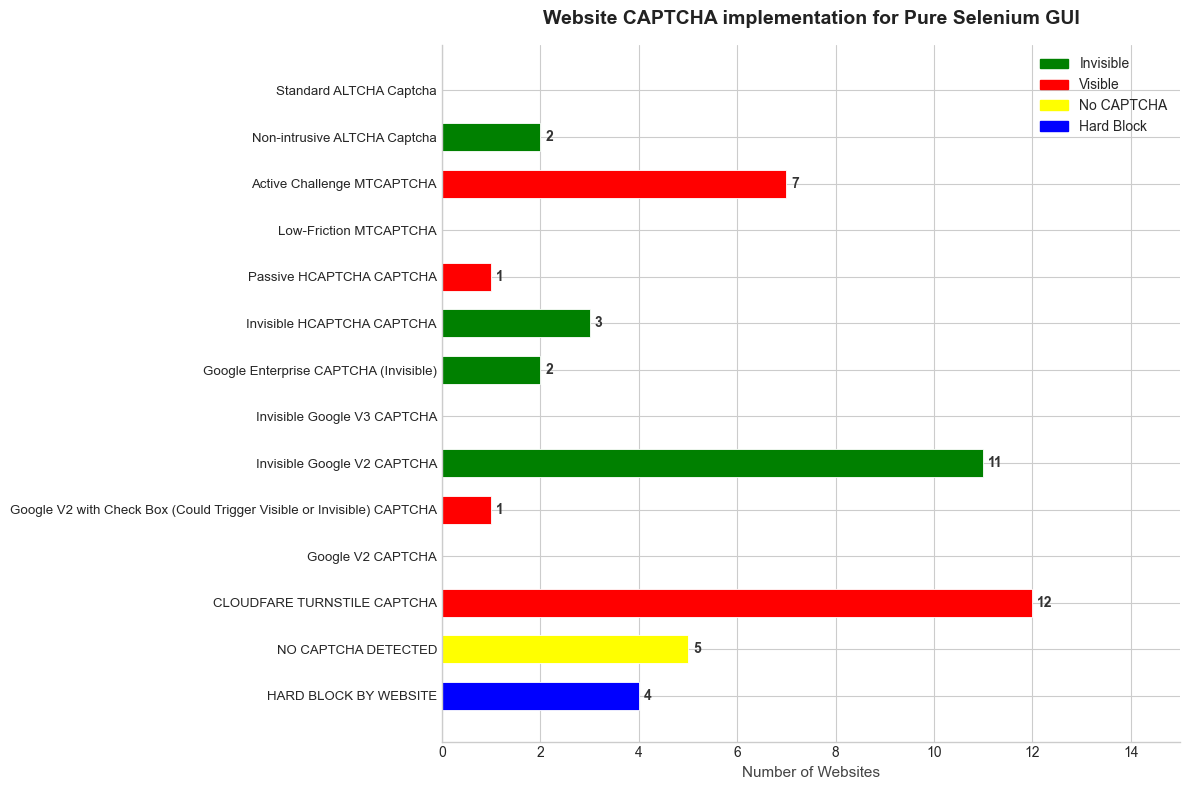

In [2]:
horizontalBarGraph(PURE_SELENIUM_GUI, "Website CAPTCHA implementation for Pure Selenium GUI", "PureSeleniumGUI.png")

# Pure Selenium Headless

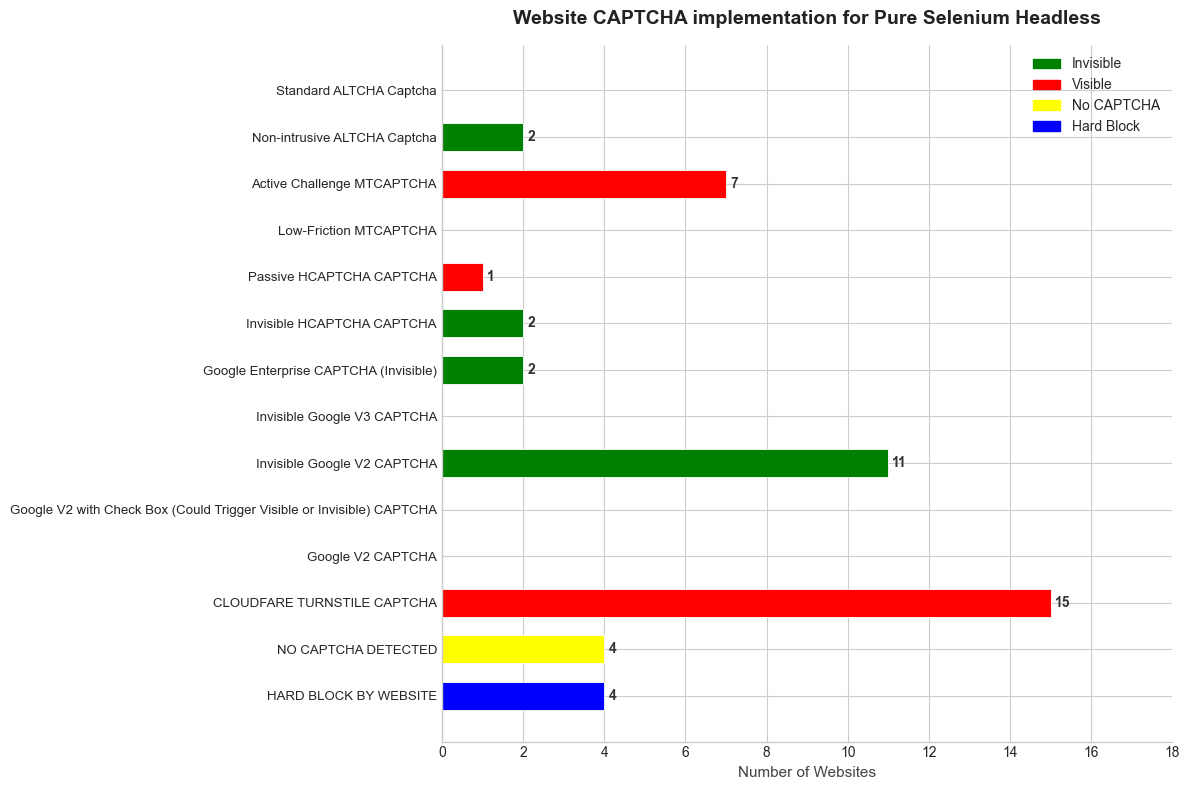

In [3]:
horizontalBarGraph(PURE_SELENIUM_HEADLESS, "Website CAPTCHA implementation for Pure Selenium Headless", "PureSeleniumHeadless.png")

# Non-Mobile GUI

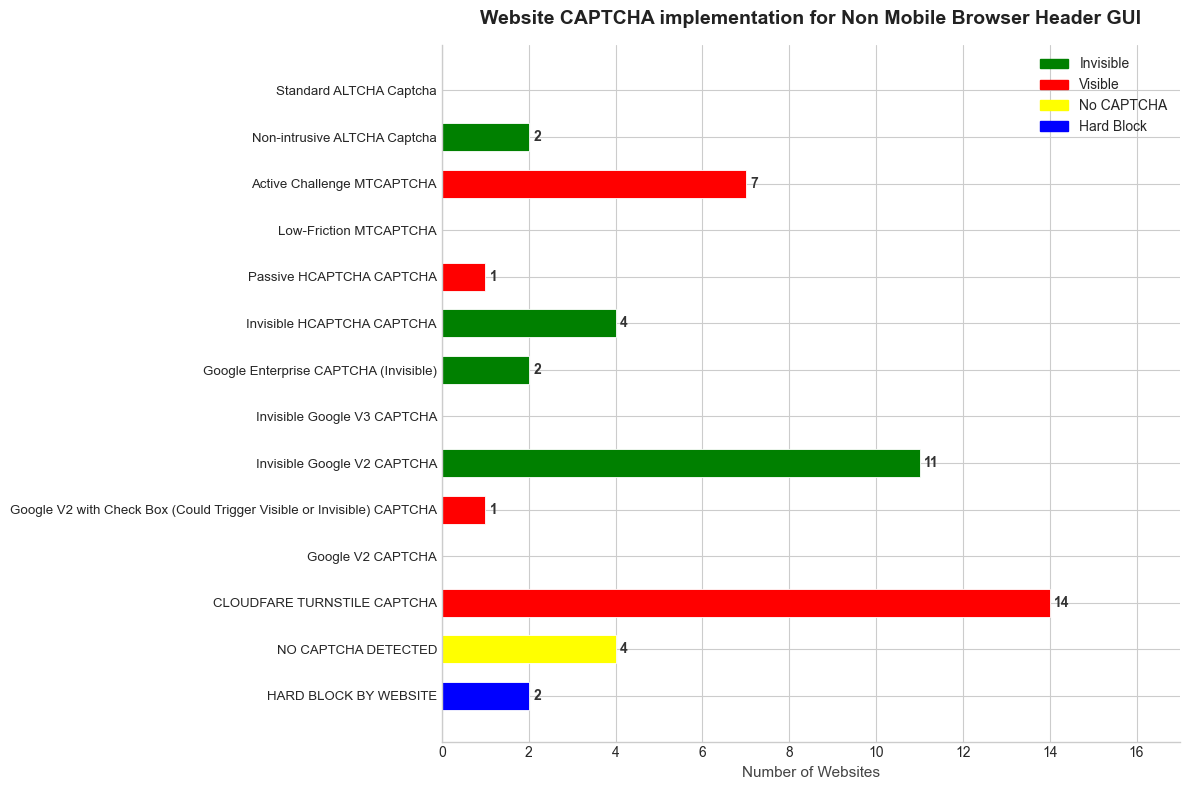

In [4]:
horizontalBarGraph(NON_MOBILE_GUI, "Website CAPTCHA implementation for Non Mobile Browser Header GUI", "NonMobileHeaderGUI.png")

# Non-Mobile Headless

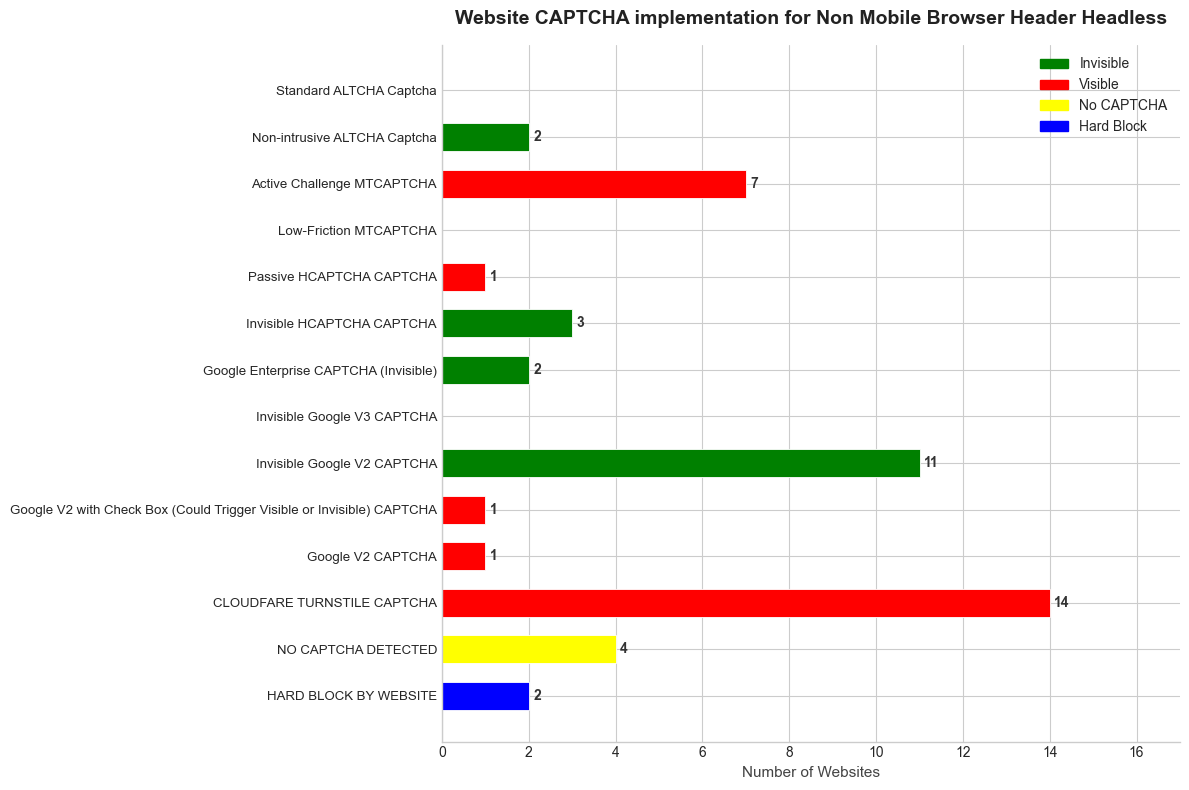

In [5]:
horizontalBarGraph(NON_MOBILE_HEADLESS, "Website CAPTCHA implementation for Non Mobile Browser Header Headless", "NonMobileHeaderHeadless.png")

# Mobile GUI

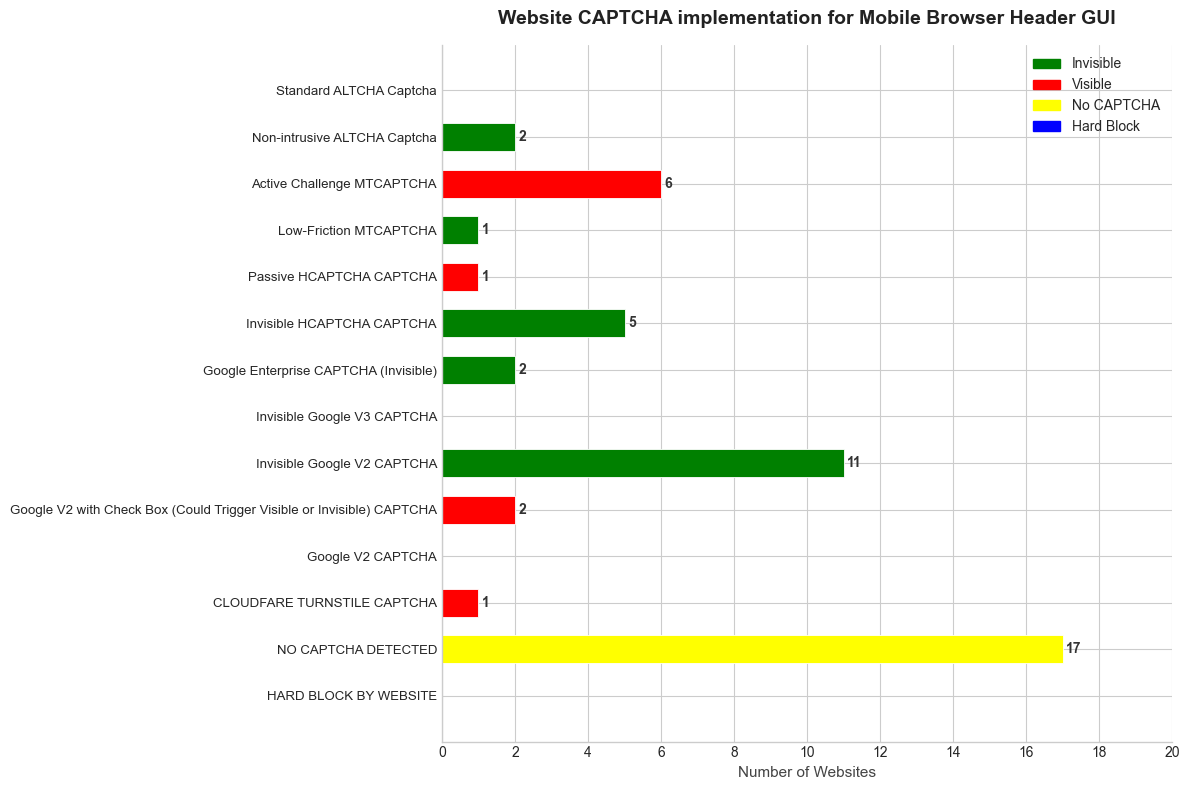

In [6]:
horizontalBarGraph(MOBILE_GUI, "Website CAPTCHA implementation for Mobile Browser Header GUI", "MobileHeaderGUI.png")

# Mobile Headless

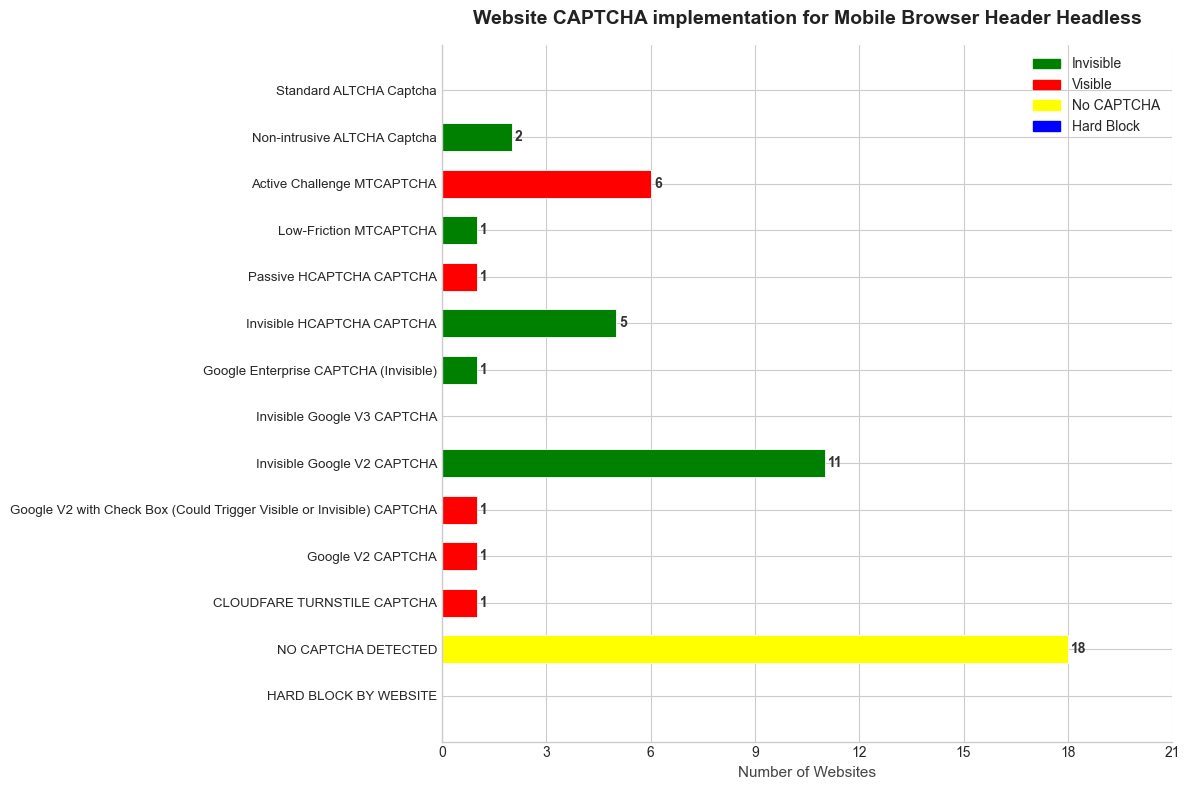

In [7]:
horizontalBarGraph(MOBILE_HEADLESS, "Website CAPTCHA implementation for Mobile Browser Header Headless", "MobileHeaderHeadless.png")

### Undetected Chrome Driver GUI

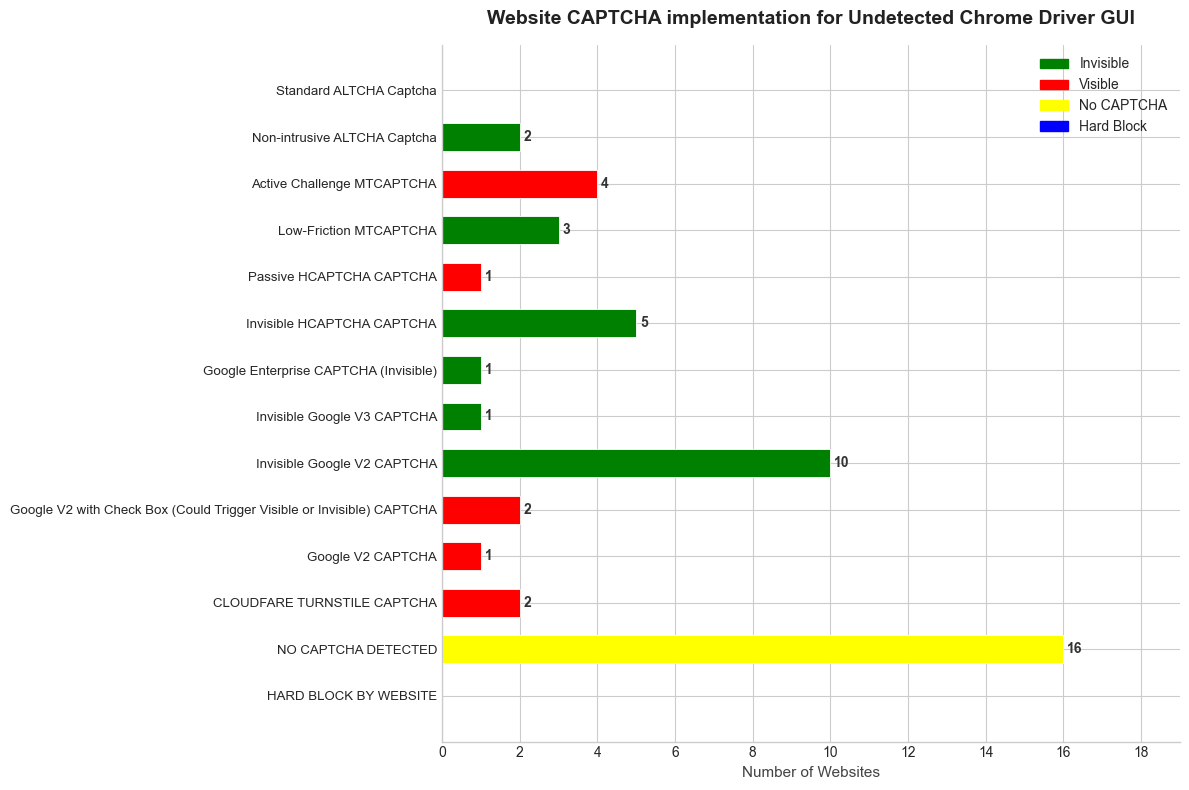

In [8]:
horizontalBarGraph(UD_GUI, "Website CAPTCHA implementation for Undetected Chrome Driver GUI", "UndetectedChromeGUI.png")

### Undetected Chrome Driver Headless

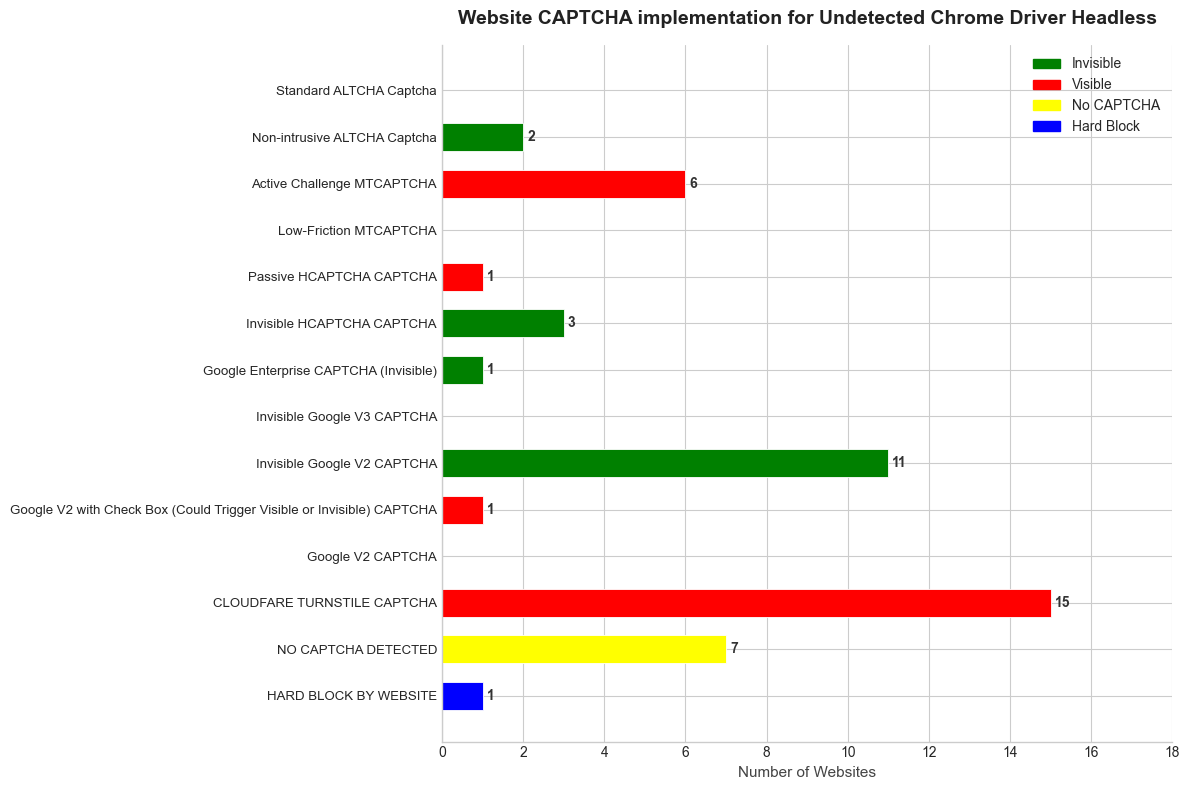

In [9]:
horizontalBarGraph(UD_HEADLESS, "Website CAPTCHA implementation for Undetected Chrome Driver Headless", "UndetectedChromeHeadless.png")

# ScrapeOPS GUI

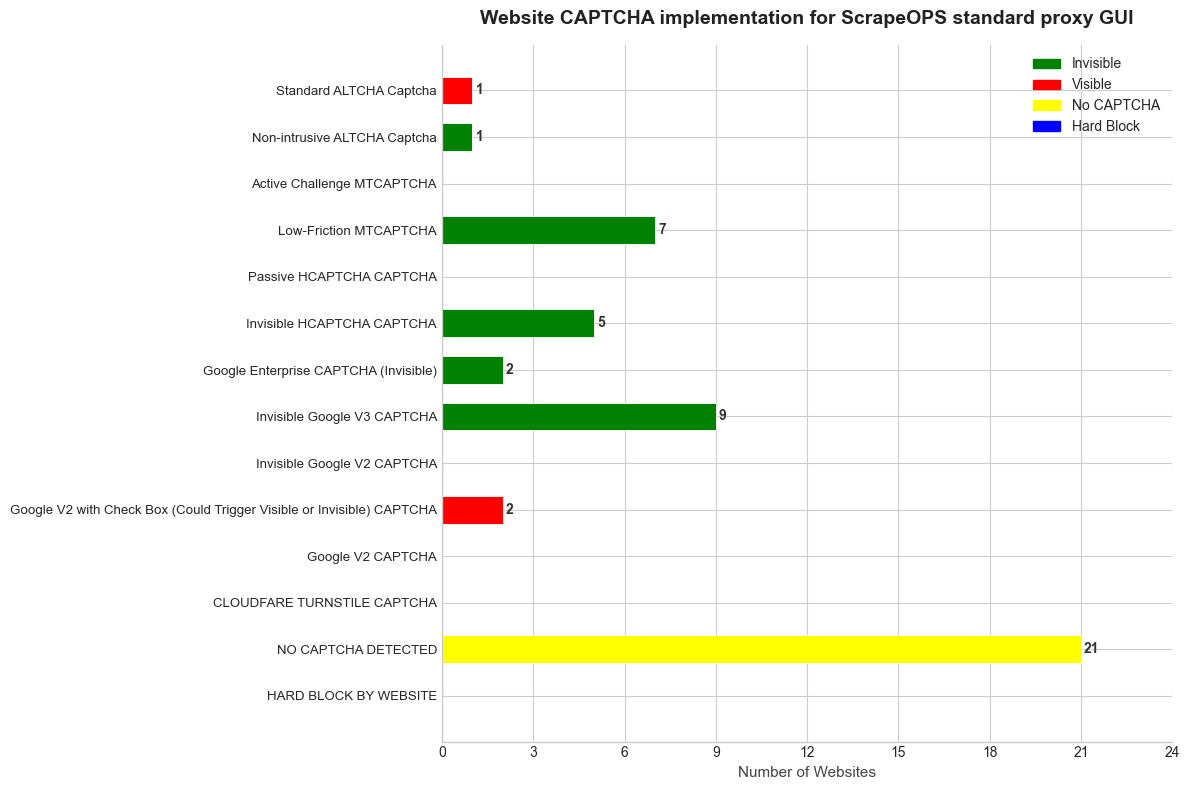

In [10]:
horizontalBarGraph(SCRAPEOPS_GUI, "Website CAPTCHA implementation for ScrapeOPS standard proxy GUI", "ScrapeOpsGUI.png") 

# ScrapeOPS Headless

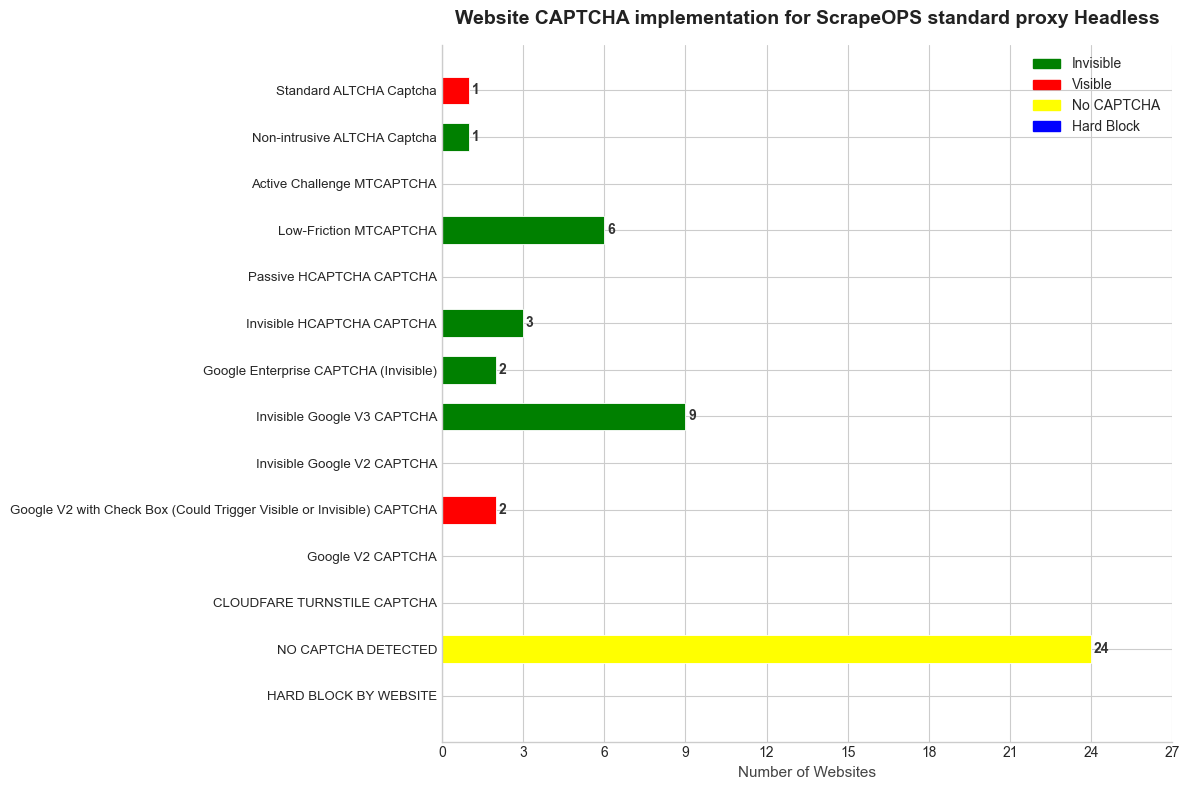

In [11]:
horizontalBarGraph(SCRAPEOPS_HEADLESS, "Website CAPTCHA implementation for ScrapeOPS standard proxy Headless", "ScrapeOpsHeadless.png") 